<a href="https://colab.research.google.com/github/risyadksm/PCVK_GANJIL_2025/blob/main/QUIZ1_PCVK_SOAL_NO_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure
from google.colab import files
import io
from PIL import Image

Upload gambar KTM Anda:


Saving KTM.jpg to KTM.jpg
File uploaded: KTM.jpg
Ukuran gambar: (1560, 2764, 3)


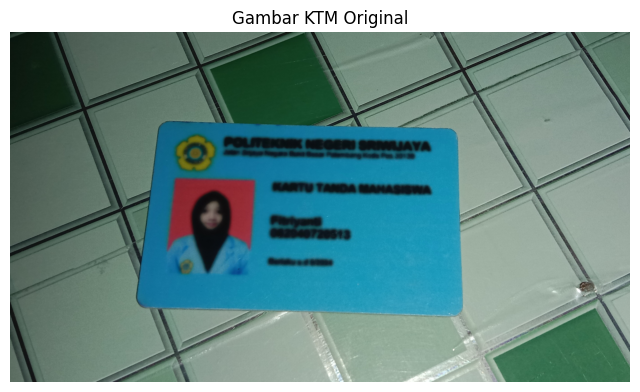

In [2]:
print("Upload gambar KTM Anda:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"File uploaded: {filename}")

img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f"Ukuran gambar: {img.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Gambar KTM Original')
plt.axis('off')
plt.show()

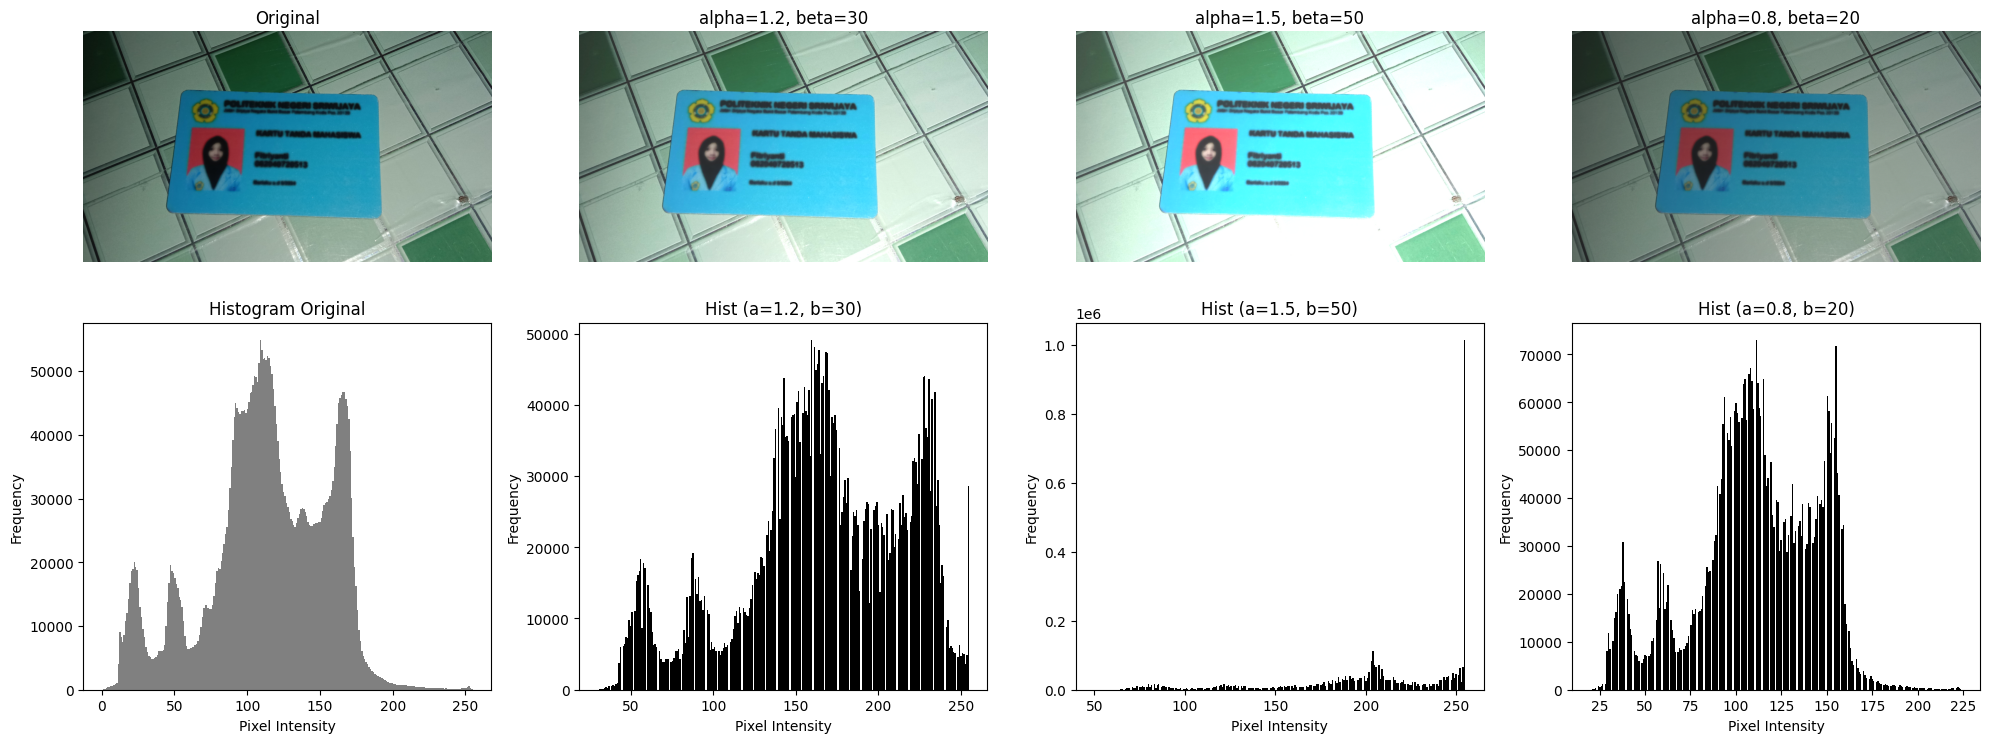

In [42]:
params = [
    (1.2, 30),   # Sedikit lebih cerah
    (1.5, 50),   # Lebih cerah
    (0.8, 20),   # Sedikit gelap
]

# Jumlah total gambar termasuk original
n = len(params) + 1

plt.figure(figsize=(5 * n, 8))

# ---- Original ----
# Gambar
plt.subplot(2, n, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

# Histogram
plt.subplot(2, n, n + 1)
plt.hist(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).ravel(), bins=256, color='gray')
plt.title('Histogram Original')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# ---- Hasil brightness/contrast ----
for i, (alpha, beta) in enumerate(params, start=2):
    # Terapkan brightness/contrast
    bright_img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    bright_rgb = cv2.cvtColor(bright_img, cv2.COLOR_BGR2RGB)

    # Gambar hasil
    plt.subplot(2, n, i)
    plt.imshow(bright_rgb)
    plt.title(f'alpha={alpha}, beta={beta}')
    plt.axis('off')

    # Histogram hasil
    plt.subplot(2, n, n + i)
    plt.hist(cv2.cvtColor(bright_img, cv2.COLOR_BGR2GRAY).ravel(), bins=256, color='black')
    plt.title(f'Hist (a={alpha}, b={beta})')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


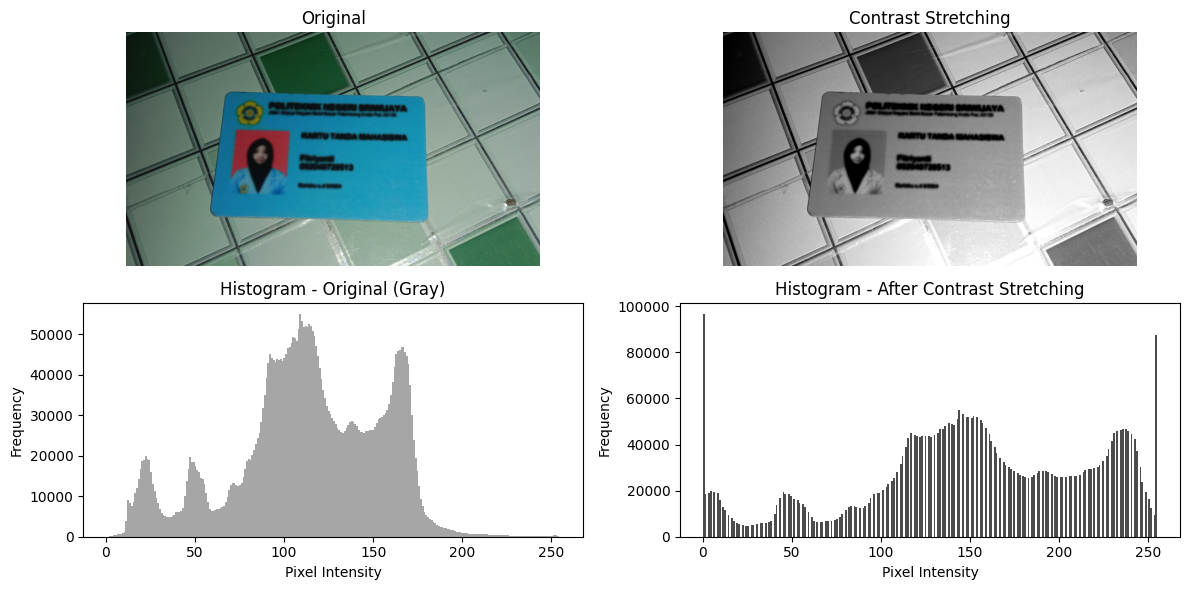

In [39]:
# Konversi gambar ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Hitung nilai persentil 2 dan 98
p2, p98 = np.percentile(gray, (2, 98))

# Lakukan contrast stretching
stretched = exposure.rescale_intensity(gray, in_range=(p2, p98), out_range=(0, 255))

# Konversi kembali ke RGB
contrast_img = cv2.cvtColor(stretched.astype(np.uint8), cv2.COLOR_GRAY2RGB)

# Visualisasi hasil gambar
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(contrast_img)
plt.title('Contrast Stretching')
plt.axis('off')

# Histogram sebelum stretching
plt.subplot(2, 2, 3)
plt.hist(gray.ravel(), bins=256, color='gray', alpha=0.7)
plt.title('Histogram - Original (Gray)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Histogram sesudah stretching
plt.subplot(2, 2, 4)
plt.hist(stretched.ravel(), bins=256, color='black', alpha=0.7)
plt.title('Histogram - After Contrast Stretching')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

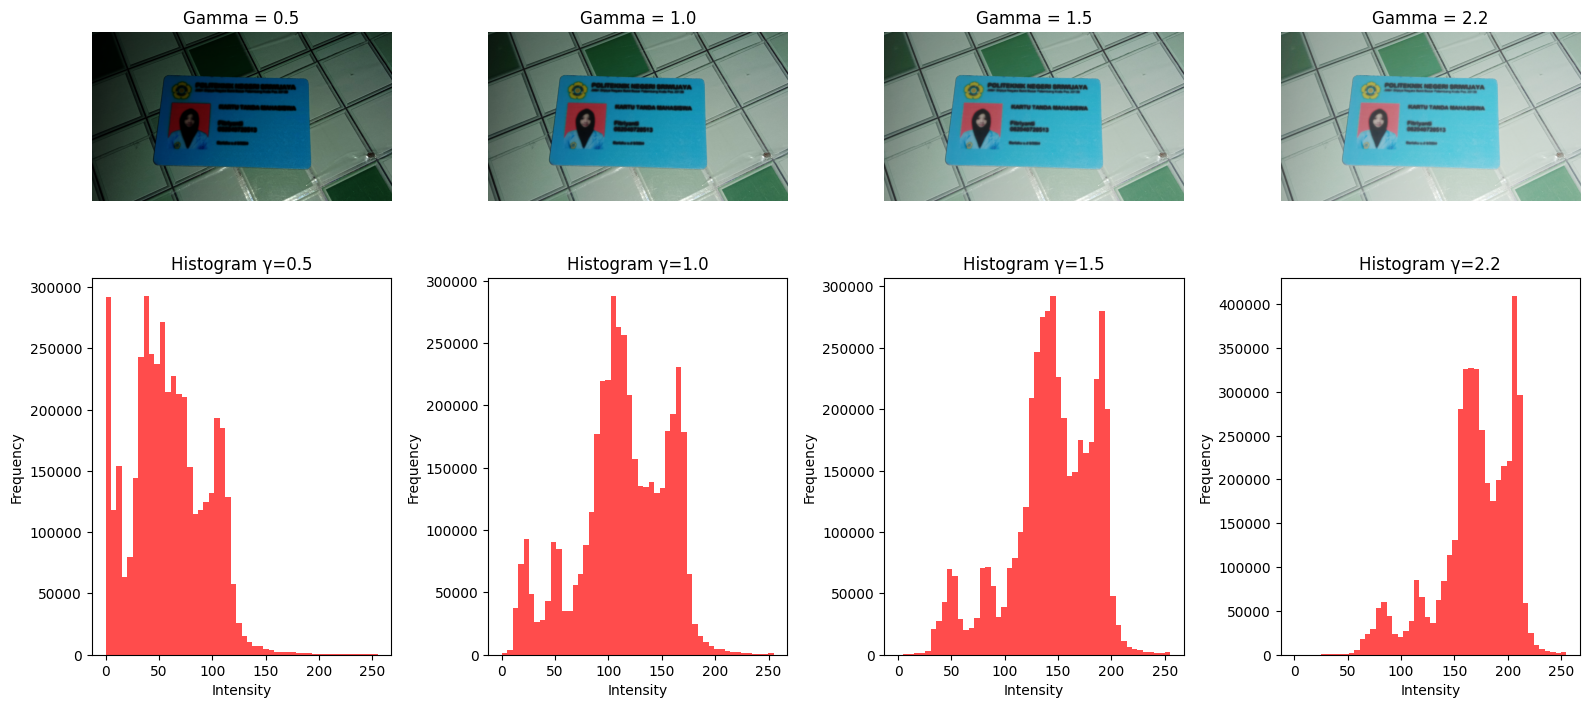

In [34]:
# Nilai gamma yang ingin diuji
gamma_values = [0.5, 1.0, 1.5, 2.2]

plt.figure(figsize=(16, 8))

for i, gamma in enumerate(gamma_values, 1):
    # Normalisasi gambar ke rentang [0, 1]
    normalized = img_rgb.astype(np.float32) / 255.0

    # Gamma correction
    corrected = np.power(normalized, 1.0 / gamma)

    # Kembalikan ke [0, 255] dan konversi ke uint8
    gamma_img = (corrected * 255).astype(np.uint8)

    # Gambar hasil gamma correction
    plt.subplot(2, 4, i)
    plt.imshow(gamma_img)
    plt.title(f'Gamma = {gamma}')
    plt.axis('off')

    # Konversi ke grayscale dan tampilan histogramnya
    gray_gamma = cv2.cvtColor(gamma_img, cv2.COLOR_RGB2GRAY)
    plt.subplot(2, 4, i + 4)
    plt.hist(gray_gamma.flatten(), bins=50, alpha=0.7, color='red')
    plt.title(f'Histogram γ={gamma}')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

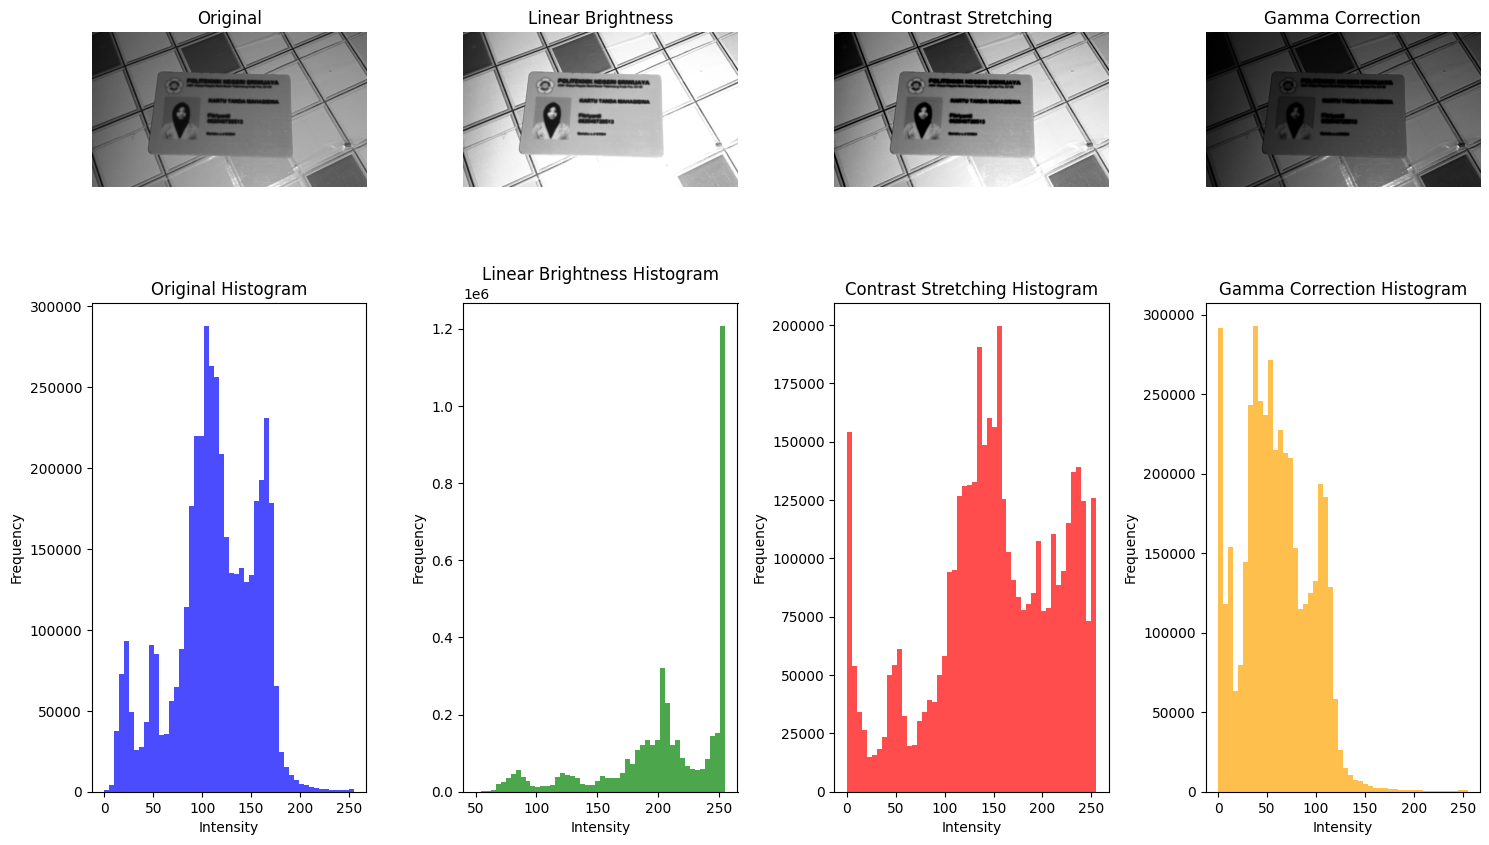

In [38]:
plt.figure(figsize=(15, 10))

# Konversi semua gambar hasil transformasi ke grayscale
original_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
linear_gray = cv2.cvtColor(bright_best_rgb, cv2.COLOR_RGB2GRAY)
contrast_gray = cv2.cvtColor(contrast_img, cv2.COLOR_RGB2GRAY)
gamma_gray = cv2.cvtColor(gamma_best, cv2.COLOR_RGB2GRAY)

# Simpan ke dalam dictionary untuk loop
transformations = {
    'Original': original_gray,
    'Linear Brightness': linear_gray,
    'Contrast Stretching': contrast_gray,
    'Gamma Correction': gamma_gray
}

# Tampilkan gambar grayscale
for i, (name, gray_img) in enumerate(transformations.items(), 1):
    plt.subplot(2, 4, i)
    plt.imshow(gray_img, cmap='gray')
    plt.title(name)
    plt.axis('off')

# Tampilkan histogram untuk masing-masing gambar
colors = ['blue', 'green', 'red', 'orange']
for i, (name, gray_img) in enumerate(transformations.items(), 5):
    plt.subplot(2, 4, i)
    plt.hist(gray_img.flatten(), bins=50, alpha=0.7, color=colors[i-5])
    plt.title(f'{name} Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [45]:
print("\n" + "="*50)
print("KESIMPULAN DAN ANALISIS")
print("="*50)

# Hitung kontras untuk menentukan yang terbaik
contrasts = {}
for name, img_gray in transformations.items():
    contrasts[name] = np.std(img_gray)

# Cari transformasi dengan kontras tertinggi
best_transform = max(contrasts.keys(), key=lambda x: contrasts[x])
best_contrast = contrasts[best_transform]

print(f"\n1. TRANSFORMASI PALING EFEKTIF:")
print(f"   {best_transform}")
print(f"   Kontras (Std Dev): {best_contrast:.2f}")

print(f"\n2. RANKING BERDASARKAN KONTRAS:")
sorted_transforms = sorted(contrasts.items(), key=lambda x: x[1], reverse=True)
for i, (name, contrast) in enumerate(sorted_transforms, 1):
    print(f"   {i}. {name}: {contrast:.2f}")

print(f"\n3. ALASAN TRANSFORMASI TERBAIK:")
print(f"   - {best_transform} memiliki standar deviasi tertinggi ({best_contrast:.2f})")
print(f"   - Kontras tinggi membantu memisahkan teks dari background")
print(f"   - Keterbacaan teks pada KTM menjadi lebih baik")
print(f"   - Distribusi intensitas piksel lebih merata")

print(f"\n4. DISTRIBUSI INTENSITAS PIKSEL:")
for name in transformations:
    if name == best_transform:
        gray_img = transformations[name]
        print(f"   {name}:")
        print(f"   - Range intensitas: {np.min(gray_img)} - {np.max(gray_img)}")
        print(f"   - Mean intensity: {np.mean(gray_img):.2f}")
        print(f"   - Kontras (Std): {np.std(gray_img):.2f}")
        break


KESIMPULAN DAN ANALISIS

1. TRANSFORMASI PALING EFEKTIF:
   Contrast Stretching
   Kontras (Std Dev): 66.18

2. RANKING BERDASARKAN KONTRAS:
   1. Contrast Stretching: 66.18
   2. Linear Brightness: 49.82
   3. Original: 42.10
   4. Gamma Correction: 35.08

3. ALASAN TRANSFORMASI TERBAIK:
   - Contrast Stretching memiliki standar deviasi tertinggi (66.18)
   - Kontras tinggi membantu memisahkan teks dari background
   - Keterbacaan teks pada KTM menjadi lebih baik
   - Distribusi intensitas piksel lebih merata

4. DISTRIBUSI INTENSITAS PIKSEL:
   Contrast Stretching:
   - Range intensitas: 0 - 255
   - Mean intensity: 150.12
   - Kontras (Std): 66.18
